# LINEAR_SVM_init.ipynb

In [60]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics
#from astroML.datasets import fetch_LINEAR_geneva

In [61]:
#data = fetch_LINEAR_geneva()
#df = pd.DataFrame(data)
#df.to_csv('LINEAR.csv', index=False)
df = pd.read_csv('LINEAR.csv')
df

,ra,dec,ug,gi,iK,JK,logP,Ampl,skew,kurt,magMed,nObs,LCtype,LINEARobjectID
0,119.526443,46.962120,1.166,0.369,1.018,0.269,-0.254138,0.619,-0.313,-0.567,16.37,301,1,29848
1,119.324013,47.095505,1.356,0.521,1.167,0.311,-0.244691,0.709,-0.493,-0.997,15.02,289,1,32086
2,118.503448,49.686569,1.166,0.138,1.154,0.384,-0.609386,0.601,-0.052,-0.447,16.14,245,1,43542
3,119.712975,52.149574,1.175,0.386,1.100,0.205,-0.191591,0.487,-0.291,-0.879,16.46,284,1,50402
4,118.491257,53.168125,0.805,0.554,1.618,0.198,-0.178900,0.695,-0.026,-1.059,14.08,274,1,61011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,169.572021,-0.245896,1.107,0.383,1.200,0.451,0.173406,0.746,2.564,6.464,15.95,434,5,24209652
6142,168.000458,11.501586,1.463,0.664,1.193,0.431,-0.467688,0.388,0.389,-0.602,14.17,535,5,24211479
6143,168.818787,12.683557,1.630,0.874,1.687,0.606,-0.117362,0.462,2.539,5.885,14.99,528,4,24215207
6144,169.745926,-14.120813,1.402,0.887,1.923,0.500,-0.527772,0.734,1.139,0.511,16.83,104,5,24264418


In [62]:
df_reduced = df.drop(['ra','dec','LINEARobjectID','nObs','magMed'],axis=1).copy()
df_reduced

,ug,gi,iK,JK,logP,Ampl,skew,kurt,LCtype
0,1.166,0.369,1.018,0.269,-0.254138,0.619,-0.313,-0.567,1
1,1.356,0.521,1.167,0.311,-0.244691,0.709,-0.493,-0.997,1
2,1.166,0.138,1.154,0.384,-0.609386,0.601,-0.052,-0.447,1
3,1.175,0.386,1.100,0.205,-0.191591,0.487,-0.291,-0.879,1
4,0.805,0.554,1.618,0.198,-0.178900,0.695,-0.026,-1.059,1
...,...,...,...,...,...,...,...,...,...
6141,1.107,0.383,1.200,0.451,0.173406,0.746,2.564,6.464,5
6142,1.463,0.664,1.193,0.431,-0.467688,0.388,0.389,-0.602,5
6143,1.630,0.874,1.687,0.606,-0.117362,0.462,2.539,5.885,4
6144,1.402,0.887,1.923,0.500,-0.527772,0.734,1.139,0.511,5


In [63]:
df_reduced.describe()

,ug,gi,iK,JK,logP,Ampl,skew,kurt,LCtype
count,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000
mean,1.310343,0.412647,1.258091,0.375767,-0.368632,0.524334,0.401108,1.699075,2.835991
std,0.345097,0.480758,0.483775,0.202392,0.205850,2.229626,1.275248,9.920221,1.857874
min,-2.201000,-1.987000,-0.852000,-0.477000,-1.376182,-99.990000,-2.407000,-1.631000,1.000000
25%,1.150000,0.110000,0.938000,0.236000,-0.515704,0.416000,-0.402000,-0.904000,1.000000
50%,1.197000,0.316000,1.169000,0.354000,-0.344812,0.536000,0.158000,-0.526000,2.000000
75%,1.342000,0.674000,1.484000,0.515000,-0.230275,0.706000,0.754750,0.284000,5.000000
max,2.750000,3.615000,5.398000,1.189000,1.529000,1.651000,12.665000,195.465000,6.000000


Ampl has -99 or some crazy number because we couldn't have NAN back in the days.

In [64]:
df_reduced.mean()/df_reduced.median()

ug        1.094689
gi        1.305845
iK        1.076211
JK        1.061490
logP      1.069083
Ampl      0.978235
skew      2.538659
kurt     -3.230180
LCtype    1.417995
dtype: float64

In [65]:
np.mean(df_reduced, axis=0)/np.median(df_reduced, axis=0)

ug        1.094689
gi        1.305845
iK        1.076211
JK        1.061490
logP      1.069083
Ampl      0.978235
skew      2.538659
kurt     -3.230180
LCtype    1.417995
dtype: float64

In [66]:
#Inter quartile range (IQR) is the difference between the 75th and 25th percentiles of the data. It is a measure of statistical dispersion and can be used to identify outliers in the data. A common rule of thumb is that any data point that is more than 1.5 times the IQR above the 75th percentile or below the 25th percentile is considered an outlier.
IQR = np.percentile(df_reduced, 75, axis=0) - np.percentile(df_reduced, 25, axis=0)
IQR

array([0.192     , 0.564     , 0.546     , 0.279     , 0.28542878,
       0.29      , 1.15675   , 1.188     , 4.        ])

In [67]:
np.std(df_reduced,axis=0)/(IQR/2)

ug         3.594470
gi         1.704676
iK         1.771926
JK         1.450724
logP       1.442272
Ampl      15.375483
skew       2.204702
kurt      16.699350
LCtype     0.928862
dtype: float64

In [68]:
#remove outliers using 5 sigma
#imputing all -99.99 values with the median value of the column
df_reduced['Ampl'] = df_reduced['Ampl'].replace(-99.99,df_reduced['Ampl'].median())

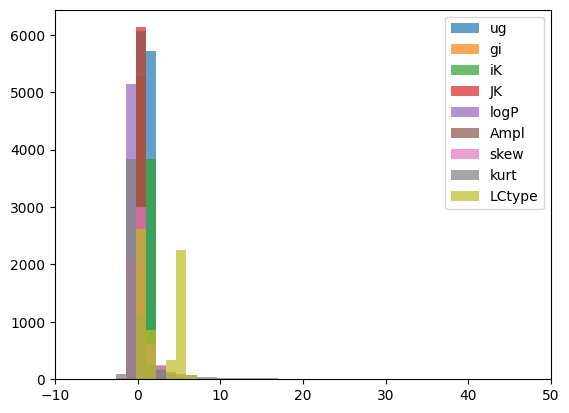

In [69]:
fig1 = plt.figure()

for i,x in enumerate(df_reduced.columns):
    plt.hist(df_reduced[df_reduced.columns[i]], label=f"{x}",alpha = 0.7,bins=np.linspace(-10,50,50))
plt.legend(loc='best')
plt.xlim(-10,50);

<Figure size 640x480 with 0 Axes>

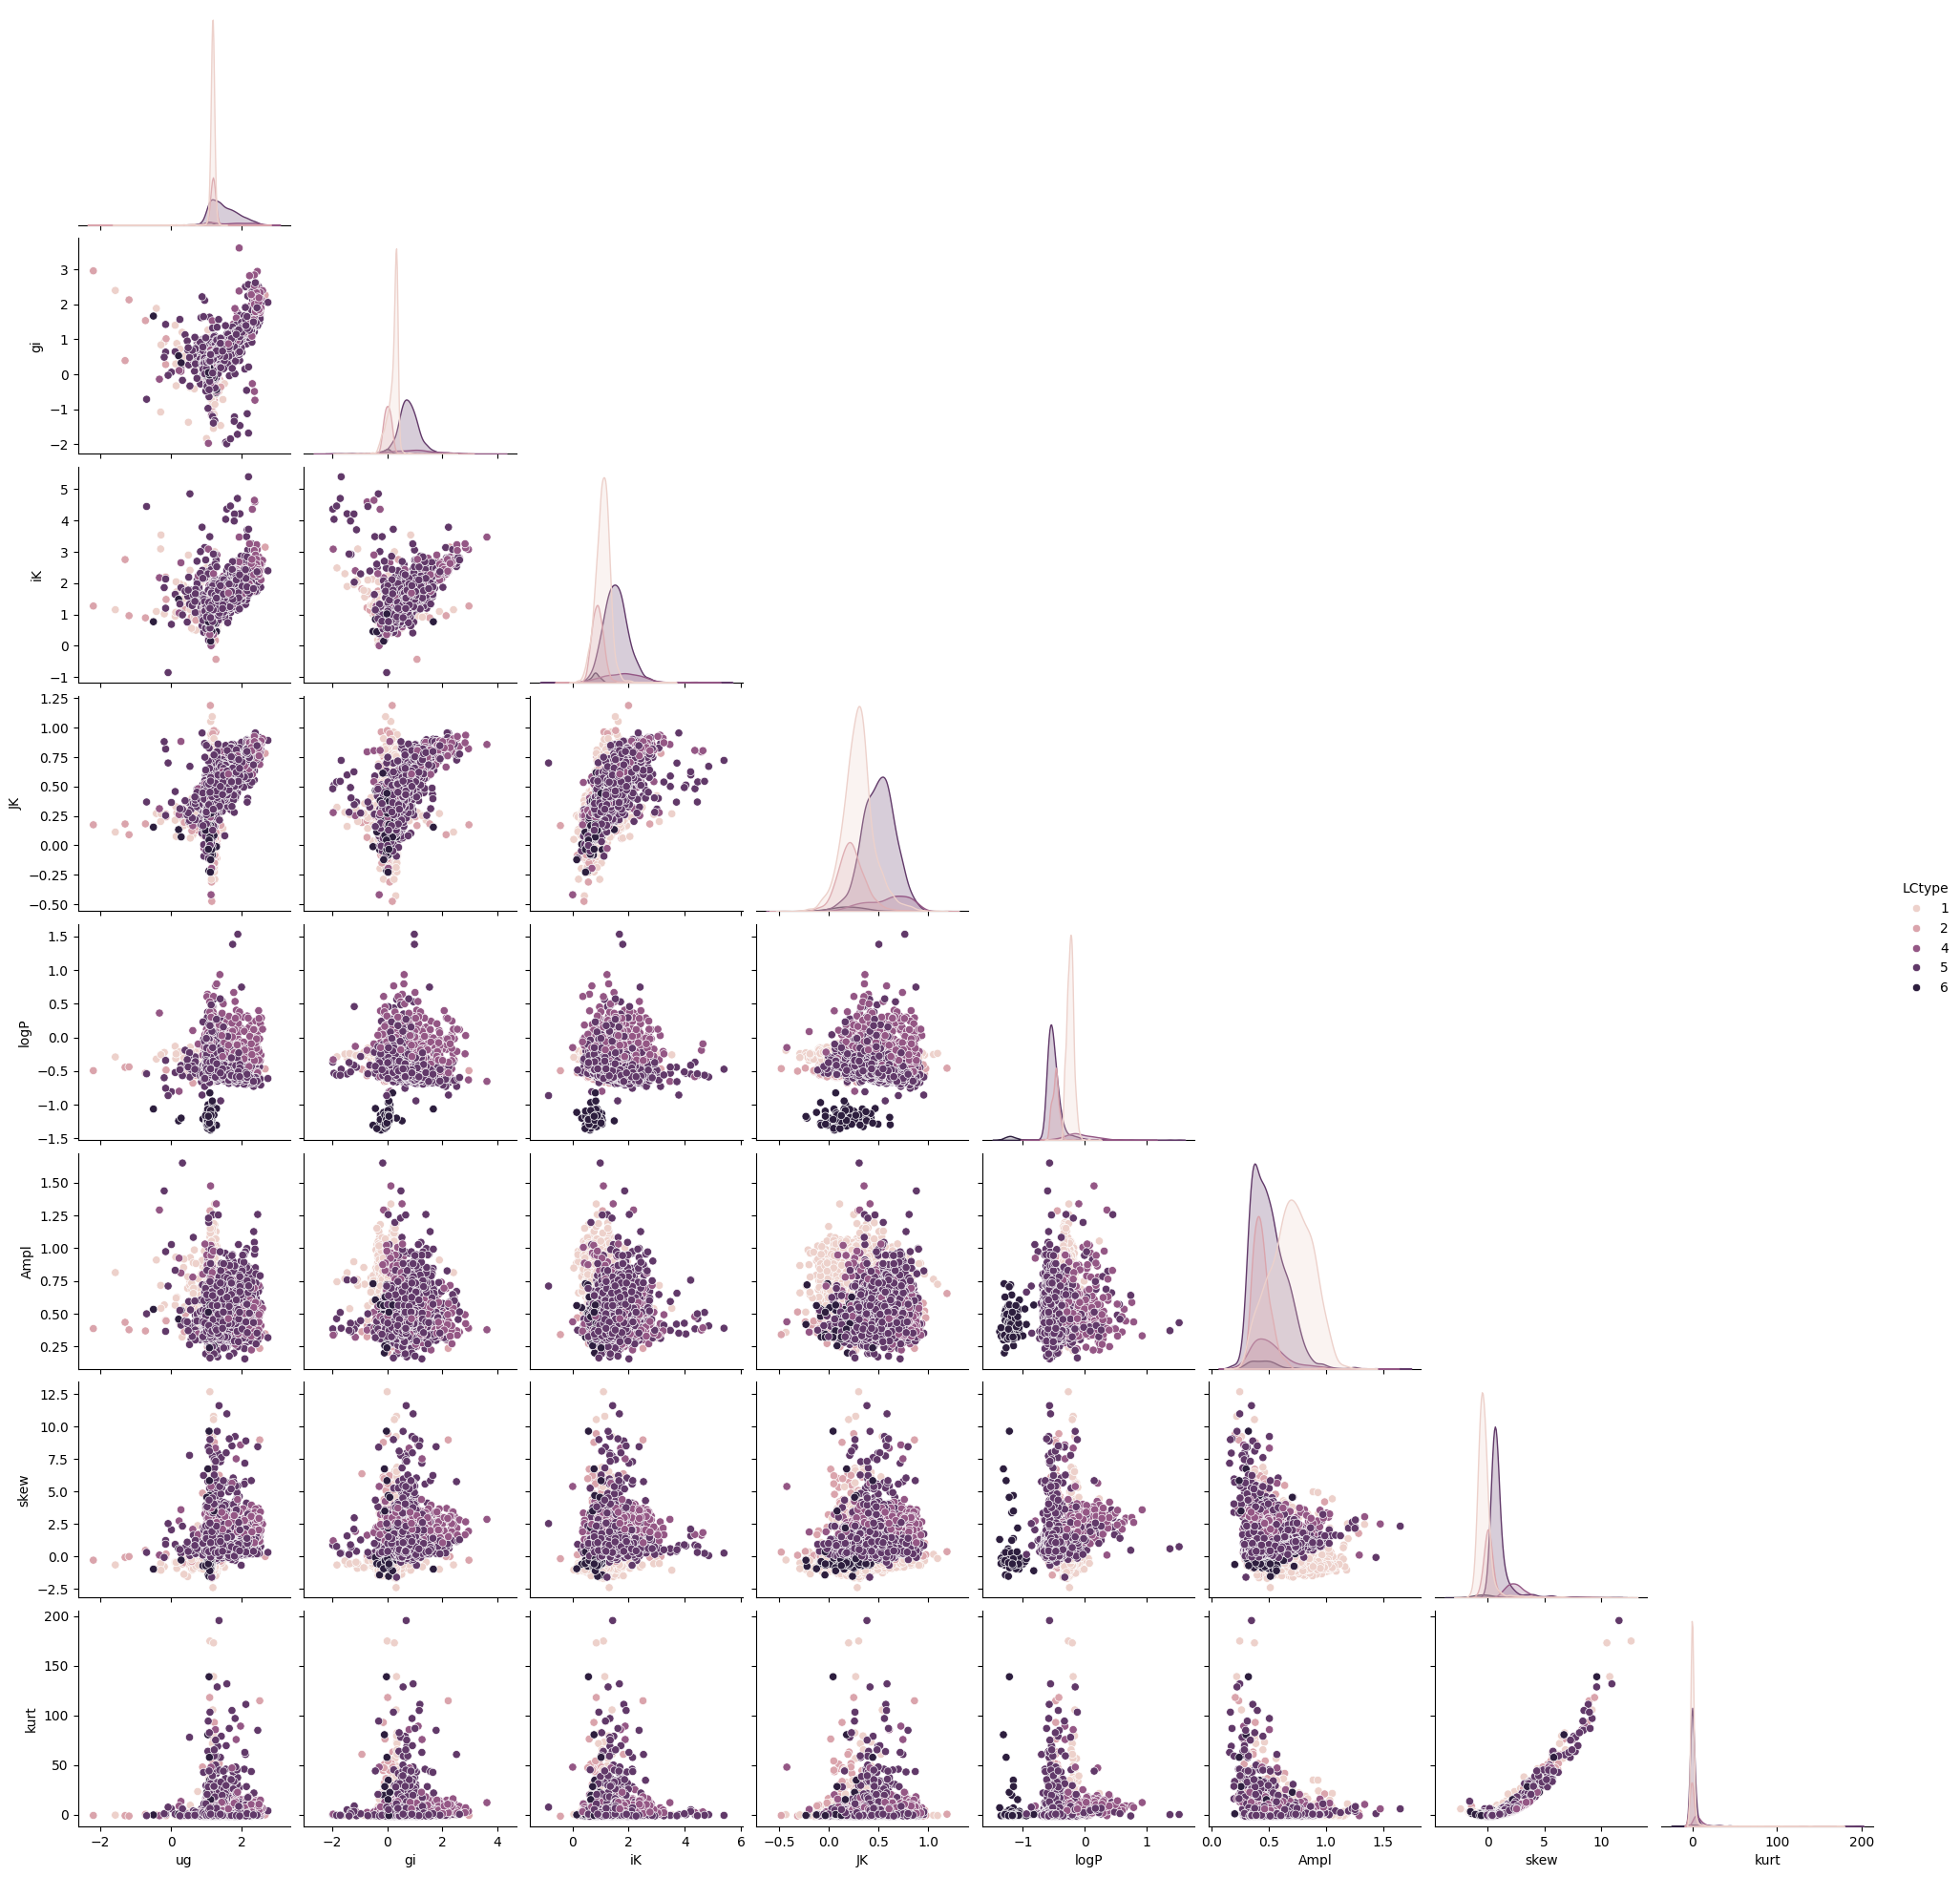

In [70]:
fig2 = plt.figure()
sns.pairplot(df_reduced,corner=True, hue = 'LCtype');

Scaling

In [71]:
#random is pseudo, round the number to get remainder over and over. artifical random
#seed --> random numbers are generated in a deterministic way, so if you set the seed to the same value, you will get the same sequence of random numbers.
#random state --> random initial state of the random number generator, which can be used to ensure reproducibility of results. By setting the random state to a specific value, you can ensure that the same sequence of random numbers is generated each time you run the code, which can be useful for debugging and comparing results across different runs.
piped_model = make_pipeline(RobustScaler(), SVC(random_state = 47, kernel='linear', C=1))

#random state --> randomly shuffling
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=57)

In [72]:
Xlearn = df_reduced.drop('LCtype',axis=1)
ylearn = df_reduced['LCtype']
#axis =1 , dataframe doesn't know what we're trying to do
#axis =0  is column, axis = 1 is row
model_results = cross_validate(piped_model, df_reduced.drop('LCtype',axis=1),df_reduced['LCtype'],cv=cv)

for key in model_results.keys():
    print(f"{key}:\n{model_results[key]}\n")

fit_time:
[0.60141253 0.48401284 0.43197918 0.42430472 0.48203611]

score_time:
[0.03527021 0.03837729 0.02808905 0.028234   0.02983975]

test_score:
[0.93658537 0.93327909 0.95117982 0.92839707 0.93816111]



<Axes: >

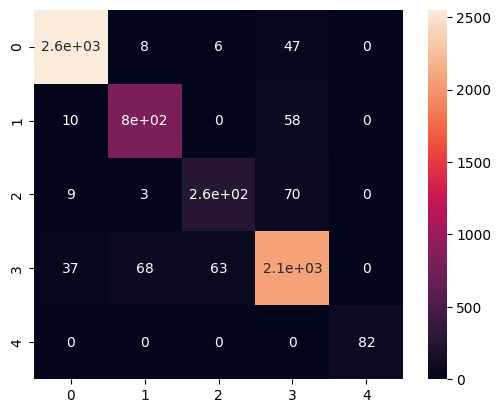

In [73]:
y_pred = cross_val_predict(piped_model, Xlearn, ylearn)
cm = metrics.confusion_matrix(ylearn, y_pred)

fig3 = plt.figure()
sns.heatmap(cm, square=True,annot=True)